# **Laboratorio 7 - Spark MLlib**

CC3084 Data Science - Universidad del Valle de Guatemala

## **0. Configuración del entorno**

Se crea la sesión con Spark, se establecen las rutas y columnas principales a consultar.

In [1]:
import time
from collections import Counter
from functools import reduce
from pathlib import Path

import pandas as pd
from openpyxl import load_workbook
from pyspark.sql import DataFrame, SparkSession, functions as F, types as T

# El notebook vive en notebooks/; la raíz del proyecto es la carpeta de arriba
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_RAW = RAIZ / "data" / "raw"
DIR_PROCESSED = RAIZ / "data" / "processed"
DIR_PROCESSED.mkdir(parents=True, exist_ok=True)

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("lab7_eneic")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8") # datos pequeños: evita 200 particiones vacías
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version, "| raíz:", RAIZ)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 20:40:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/09/24 20:40:14 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark 3.5.1 | raíz: /opt/app


In [2]:
# Archivo de procedencia de cada período. El período sale del ARCHIVO, no de la columna TRIMESTRE.
ARCHIVOS = {
    # período: (archivo, año, trimestre, uso)
    "2025T1": ("personas_eneic_2025t1.xlsx", 2025, 1, "entrenamiento"),
    "2025T2": ("personas_eneic_2025t2.xlsx", 2025, 2, "entrenamiento"),
    "2025T3": ("personas_eneic_2025t3.xlsx", 2025, 3, "entrenamiento"),
    "2025T4": ("personas_eneic_2025t4.xlsx", 2025, 4, "validación"),
    "2026T1": ("personas_eneic_2026t1.xlsx", 2026, 1, "prueba"),
}

# Registros originales según el enunciado (se verifican al cargar)
FILAS_ESPERADAS = {"2025T1": 51_588, "2025T2": 51_167, "2025T3": 51_583, "2025T4": 49_338, "2026T1": 49_843}

# Columnas que se leen de cada Excel (las 14 que pide el enunciado)
COLUMNAS_FUENTE = [
    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", # auditoría y diseño muestral
    "OCUPADOS", # filtro
    "P02A03", "P05C07A", "P05C07B", "P05H01A", # numéricas
    "P03A03A", "P05C16", "DOMINIO", # categóricas
    "P05D01", # objetivo
]

## **1. Carga, armonización y calidad de datos**

### **1.1 Carga individual de cada archivo**

Spark no trae un lector nativo de Excel, así que cada archivo se lee con openpyxl y después se convierte a un DataFrame de Spark.

Se estuvo trabajando gestionando un archivo a la vez en modo "streaming", todo se lee como texto y cada registro guarda el archivo del que procede.

El resultado se guarda en Parquet.

In [3]:
def leer_excel(periodo):
    """Lee las COLUMNAS_FUENTE de un Excel en streaming; devuelve los registros como texto y el tipo con el que llegó cada valor."""
    archivo, anio, trim, uso = ARCHIVOS[periodo]
    wb = load_workbook(DIR_RAW / archivo, read_only=True, data_only=True)
    filas = wb.worksheets[0].iter_rows(values_only=True)

    encabezado = [str(c).strip() if c is not None else "" for c in next(filas)]
    faltan = [c for c in COLUMNAS_FUENTE if c not in encabezado]
    assert not faltan, f"{archivo}: faltan columnas {faltan}"
    posiciones = [encabezado.index(c) for c in COLUMNAS_FUENTE] # por NOMBRE, no por posición

    registros = []
    tipos = {c: Counter() for c in COLUMNAS_FUENTE}
    for fila in filas:
        valores = [fila[i] if i < len(fila) else None for i in posiciones]
        valores = [None if v is None or str(v).strip() == "" else v for v in valores] # celda vacía = nulo
        for c, v in zip(COLUMNAS_FUENTE, valores):
            if v is not None:
                tipos[c][type(v).__name__] += 1
        registros.append(tuple(None if v is None else str(v).strip() for v in valores) + (archivo, periodo, anio, trim))
    wb.close()

    return registros, len(encabezado), tipos

In [4]:
# Esquema explícito: columnas fuente como texto y columnas de trazabilidad tipadas
ESQUEMA_CRUDO = T.StructType(
    [T.StructField(c, T.StringType(), True) for c in COLUMNAS_FUENTE]
    + [
        T.StructField("archivo_origen", T.StringType(), False),
        T.StructField("periodo_archivo", T.StringType(), False),
        T.StructField("anio_archivo", T.IntegerType(), False),
        T.StructField("trimestre_calendario", T.IntegerType(), False),
    ]
)

DIR_CRUDO = DIR_PROCESSED / "01_crudo" # un parquet por archivo
resumen_carga, tipos_origen = [], []

for periodo, (archivo, anio, trim, uso) in ARCHIVOS.items():
    t0 = time.time()
    registros, n_columnas, tipos = leer_excel(periodo)
    sdf = spark.createDataFrame(registros, schema=ESQUEMA_CRUDO)
    sdf.write.mode("overwrite").parquet(str(DIR_CRUDO / f"{periodo}.parquet"))

    resumen_carga.append({
        "periodo_archivo": periodo, "archivo_origen": archivo, "uso": uso,
        "columnas_originales": n_columnas, "registros_originales": len(registros),
        "esperados_enunciado": FILAS_ESPERADAS[periodo],
    })
    tipos_origen.append({"periodo_archivo": periodo, **{c: " y ".join(sorted(t)) for c, t in tipos.items()}})
    print(f"[cargado] {archivo}: {len(registros):,} filas, {n_columnas} columnas ({time.time() - t0:.0f}s)")
    del registros, sdf

resumen_carga = pd.DataFrame(resumen_carga)
resumen_carga["coincide"] = resumen_carga["registros_originales"] == resumen_carga["esperados_enunciado"]
assert resumen_carga["coincide"].all(), "Algún archivo no tiene los registros esperados"
resumen_carga

[cargado] personas_eneic_2025t1.xlsx: 51,588 filas, 270 columnas (29s)


[cargado] personas_eneic_2025t2.xlsx: 51,167 filas, 270 columnas (10s)


[cargado] personas_eneic_2025t3.xlsx: 51,583 filas, 270 columnas (27s)


[cargado] personas_eneic_2025t4.xlsx: 49,338 filas, 302 columnas (29s)


[cargado] personas_eneic_2026t1.xlsx: 49,843 filas, 270 columnas (29s)


,periodo_archivo,archivo_origen,uso,columnas_originales,registros_originales,esperados_enunciado,coincide
0,2025T1,personas_eneic_2025t1.xlsx,entrenamiento,270,51588,51588,True
1,2025T2,personas_eneic_2025t2.xlsx,entrenamiento,270,51167,51167,True
2,2025T3,personas_eneic_2025t3.xlsx,entrenamiento,270,51583,51583,True
3,2025T4,personas_eneic_2025t4.xlsx,validación,302,49338,49338,True
4,2026T1,personas_eneic_2026t1.xlsx,prueba,270,49843,49843,True


In [5]:
crudo = {p: spark.read.parquet(str(DIR_CRUDO / f"{p}.parquet")) for p in ARCHIVOS}
print(f"Registros en el Parquet crudo: {sum(df.count() for df in crudo.values()):,}")
reduce(DataFrame.unionByName, crudo.values()).groupBy("periodo_archivo", "TRIMESTRE").count().orderBy("periodo_archivo", "TRIMESTRE").show()

Registros en el Parquet crudo: 253,519


+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025T1|        2|51588|
|         2025T2|        2|  175|
|         2025T2|        3|50992|
|         2025T3|        4|51583|
|         2025T4|        5|49338|
|         2026T1|        6|49843|
+---------------+---------+-----+



In [6]:
# Tipo con el que llega cada columna en el Excel (sin contar celdas vacías)
pd.DataFrame(tipos_origen).set_index("periodo_archivo").T

periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
ANIO,int,int,int,int,int
TRIMESTRE,int,int,int,int,int
NUM_HOGAR,int,int,int,int,int
NUM_PERSONA,int,int,int,int,int
FACTOR,int,int,int,int,int
OCUPADOS,int,str,int,int,int
P02A03,int,int,int,int,int
P05C07A,int,int,int,int,int
P05C07B,int,str,int,int,int
P05H01A,int,int,int,int,int


Se cargaron los cinco archivos con un total de 253,519 registros, de los cuales 203,676 corresponden a 2025 y 49,843 al primer trimestre de 2026, y cada archivo coincide con la cantidad de registros que indica el enunciado, por lo que la carga no perdió ni duplicó filas. Cabe mencionar que IV-2025 trae 302 columnas mientras que el resto trae 270, y al tener columnas adicionales las variables quedan en otra posición, por ejemplo, el salario pasa de la columna 105 en I-2025 a la 98 en IV-2025.

Asimismo, la columna TRIMESTRE no coincide con el trimestre calendario, ya que va de 2 en I-2025 a 6 en I-2026, y en II-2025 hay 175 registros con valor 2 en lugar de 3, es por esto que el período de cada registro se toma del archivo del que procede y TRIMESTRE se conserva sin modificar.

### **1.2 Armonización de tipos y códigos**

In [7]:
# Nombres analíticos de las variables del enunciado
RENOMBRAR = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
}
NUMERICAS = ["salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales"]

# Códigos válidos según los diccionarios de Personas (iguales en los cinco períodos)
CATEGORIAS = {
    "nivel_educativo": {
        0: "Ninguno", 1: "Preprimaria", 2: "Primaria", 3: "Básico",
        4: "Diversificado", 5: "Superior", 6: "Maestría", 7: "Doctorado",
    },
    "categoria_ocupacional": {
        1: "Empleado de gobierno", 2: "Empleado de empresa privada", 3: "Jornalero o peón",
        4: "Servicio doméstico", 5: "Cuenta propia no agrícola", 6: "Patrón no agrícola",
        7: "Cuenta propia agrícola", 8: "Patrón agrícola", 9: "No remunerado",
    },
    "dominio": {1: "Urbano Metropolitano", 2: "Resto Urbano", 3: "Rural Nacional"},
}
DESCONOCIDO = "DESCONOCIDO"

In [8]:
def a_codigo(c):
    """Convierte un código a entero: 1, "1" y "1.0" quedan igual; lo que no es un entero queda nulo."""
    x = F.col(c).cast("double")
    return F.when(x == F.floor(x), x.cast("int"))


def a_categoria(c, codigos):
    """Traduce el código a su etiqueta del diccionario; vacíos y códigos no reconocidos quedan como DESCONOCIDO."""
    mapa = F.create_map(*[F.lit(v) for par in codigos.items() for v in par])
    return F.coalesce(mapa[a_codigo(c)], F.lit(DESCONOCIDO))


def armonizar(df):
    """Homologa tipos, renombra a nombres analíticos y construye la antigüedad en años."""
    uso = F.create_map(*[F.lit(v) for p, datos in ARCHIVOS.items() for v in (p, datos[3])])
    return df.select(
        "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
        uso[F.col("periodo_archivo")].alias("uso"),
        *[a_codigo(c).alias(c) for c in ["ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA"]],
        F.col("FACTOR").cast("double").alias("FACTOR"),
        a_codigo("OCUPADOS").alias("ocupado"),
        *[F.col(o).cast("double").alias(n) for o, n in RENOMBRAR.items() if n in NUMERICAS],
        *[a_categoria(o, CATEGORIAS[n]).alias(n) for o, n in RENOMBRAR.items() if n in CATEGORIAS],
    ).withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)

In [9]:
# Valores con dato en el crudo que no corresponden a un código del diccionario
fuera_diccionario = {}
for o, n in RENOMBRAR.items():
    if n in CATEGORIAS:
        valido = F.coalesce(a_codigo(o).isin(list(CATEGORIAS[n])), F.lit(False))
        fuera_diccionario[n] = sum(df.filter(F.col(o).isNotNull() & ~valido).count() for df in crudo.values())
pd.Series(fuera_diccionario, name="valores_fuera_del_diccionario")

nivel_educativo          0
categoria_ocupacional    0
dominio                  0
Name: valores_fuera_del_diccionario, dtype: int64

In [10]:
# Cada archivo se armoniza por separado y los de 2025 se unen por nombre de columna
armonizado = {p: armonizar(df) for p, df in crudo.items()}
eneic_2025 = reduce(DataFrame.unionByName, [armonizado[p] for p in ARCHIVOS if p.startswith("2025")]).cache()
eneic_2026 = armonizado["2026T1"].cache()

print(f"2025: {eneic_2025.count():,} registros | 2026: {eneic_2026.count():,} registros")
eneic_2025.printSchema()

2025: 203,676 registros | 2026: 49,843 registros
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- uso: string (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: integer (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = false)
 |-- categoria_ocupacional: string (nullable = false)
 |-- dominio: string (nullable = false)
 |-- antiguedad: double (nullable = true)



In [11]:
eneic_2025.limit(5).toPandas()

,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario,uso,ANIO,TRIMESTRE,NUM_HOGAR,NUM_PERSONA,FACTOR,ocupado,salario_mensual,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo,categoria_ocupacional,dominio,antiguedad
0,personas_eneic_2025t1.xlsx,2025T1,2025,1,entrenamiento,2025,2,3299,1,300.0,NaN,NaN,84.0,NaN,NaN,NaN,Primaria,DESCONOCIDO,Resto Urbano,NaN
1,personas_eneic_2025t1.xlsx,2025T1,2025,1,entrenamiento,2025,2,3299,2,300.0,NaN,NaN,78.0,NaN,NaN,NaN,Primaria,DESCONOCIDO,Resto Urbano,NaN
2,personas_eneic_2025t1.xlsx,2025T1,2025,1,entrenamiento,2025,2,15607,2,318.0,1.0,1680.0,54.0,44.0,0.0,44.0,Ninguno,Jornalero o peón,Resto Urbano,44.0
3,personas_eneic_2025t1.xlsx,2025T1,2025,1,entrenamiento,2025,2,15607,3,318.0,1.0,600.0,20.0,1.0,0.0,36.0,Diversificado,Servicio doméstico,Resto Urbano,1.0
4,personas_eneic_2025t1.xlsx,2025T1,2025,1,entrenamiento,2025,2,15607,1,318.0,1.0,NaN,60.0,22.0,0.0,20.0,Ninguno,Cuenta propia no agrícola,Resto Urbano,22.0


### **1.3 Faltantes antes de los filtros**

In [12]:
def faltantes(df):
    """Cantidad y porcentaje de faltantes por variable; en las categóricas cuenta DESCONOCIDO."""
    total = df.count()
    columnas = ["ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ocupado", *NUMERICAS, "antiguedad", *CATEGORIAS]
    conteo = df.agg(*[
        F.sum(((F.col(c) == DESCONOCIDO) if c in CATEGORIAS else F.col(c).isNull()).cast("int")).alias(c)
        for c in columnas
    ]).first().asDict()
    tabla = pd.DataFrame({"faltantes": conteo})
    tabla["porcentaje"] = (100 * tabla["faltantes"] / total).round(2)
    return tabla


pd.concat({"2025": faltantes(eneic_2025), "2026T1": faltantes(eneic_2026)}, axis=1)

2025               2026T1           
                      faltantes porcentaje faltantes porcentaje
ANIO                          0       0.00         0       0.00
TRIMESTRE                     0       0.00         0       0.00
NUM_HOGAR                     0       0.00         0       0.00
NUM_PERSONA                   0       0.00         0       0.00
FACTOR                        0       0.00         0       0.00
ocupado                  115454      56.69     28109      56.40
salario_mensual          150651      73.97     36585      73.40
edad                          0       0.00         0       0.00
antiguedad_anios         115454      56.69     28109      56.40
antiguedad_meses         115454      56.69     28109      56.40
horas_semanales          115454      56.69     28109      56.40
antiguedad               115454      56.69     28109      56.40
nivel_educativo           26344      12.93      6011      12.06
categoria_ocupacional    115454      56.69     28109      56.40
dominio                       0       0.00         0       0.00

### **1.4 Filtros de la población analítica**

In [13]:
def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(c) & (F.abs(F.col(c)) < float("inf"))


ASALARIADOS = [CATEGORIAS["categoria_ocupacional"][k] for k in (1, 2, 3, 4)]

# Orden fijo: (criterio, condición para conservar el registro, columnas necesarias para evaluarlo)
FILTROS = [
    ("Edad finita y mayor o igual a 15",
     finito("edad") & (F.col("edad") >= 15), ["edad"]),
    ("Ocupado (OCUPADOS = 1)",
     F.col("ocupado") == 1, []), # nulo significa no ocupado, no es un faltante
    ("Asalariado (P05C16 de 1 a 4)",
     F.col("categoria_ocupacional").isin(ASALARIADOS), ["categoria_ocupacional"]),
    ("Salario numérico, finito y mayor a 0",
     finito("salario_mensual") & (F.col("salario_mensual") > 0), ["salario_mensual"]),
    ("Antigüedad no negativa y meses entero entre 0 y 11",
     finito("antiguedad_anios") & finito("antiguedad_meses") & (F.col("antiguedad_anios") >= 0)
     & (F.col("antiguedad_meses") == F.floor("antiguedad_meses")) & F.col("antiguedad_meses").between(0, 11),
     ["antiguedad_anios", "antiguedad_meses"]),
    ("Antigüedad menor o igual a la edad",
     F.col("antiguedad") <= F.col("edad"), ["antiguedad", "edad"]),
    ("Horas habituales mayores a 0 y hasta 168",
     finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168), ["horas_semanales"]),
]


def aplicar_filtros(df):
    """Aplica FILTROS en orden y cuenta por período los excluidos en cada paso y cuántos de ellos no tenían el dato."""
    conteos = []
    for paso, (criterio, conserva, columnas) in enumerate(FILTROS, start=1):
        cumple = F.coalesce(conserva, F.lit(False))
        sin_dato = reduce(
            lambda a, b: a | b,
            [(F.col(c) == DESCONOCIDO) if c in CATEGORIAS else F.col(c).isNull() for c in columnas],
            F.lit(False),
        )
        tabla = df.groupBy("periodo_archivo").agg(
            F.sum((~cumple).cast("int")).alias("excluidos"),
            F.sum((~cumple & sin_dato).cast("int")).alias("excluidos_sin_dato"),
        ).toPandas()
        tabla.insert(0, "criterio", criterio)
        tabla.insert(0, "paso", paso)
        conteos.append(tabla)
        df = df.filter(cumple)
    return df, pd.concat(conteos, ignore_index=True)


analitica_2025, excluidos_2025 = aplicar_filtros(eneic_2025)
analitica_2026, excluidos_2026 = aplicar_filtros(eneic_2026)
analitica_2025, analitica_2026 = analitica_2025.cache(), analitica_2026.cache()

In [14]:
excluidos = pd.concat([excluidos_2025, excluidos_2026])
tabla_excluidos = excluidos.pivot_table(index=["paso", "criterio"], columns="periodo_archivo", values="excluidos", aggfunc="sum")
tabla_excluidos["total_2025"] = tabla_excluidos[[p for p in tabla_excluidos.columns if p.startswith("2025")]].sum(axis=1)
tabla_excluidos["sin_dato_2025"] = excluidos_2025.groupby(["paso", "criterio"])["excluidos_sin_dato"].sum()
tabla_excluidos["sin_dato_2026T1"] = excluidos_2026.groupby(["paso", "criterio"])["excluidos_sin_dato"].sum()
tabla_excluidos

,periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1,total_2025,sin_dato_2025,sin_dato_2026T1
paso,criterio,,,,,,,,
1,Edad finita y mayor o igual a 15,16253,15882,15767,14984,14803,62886,0,0
2,Ocupado (OCUPADOS = 1),13062,12942,13443,13121,13306,52568,0,0
3,Asalariado (P05C16 de 1 a 4),8854,8851,8923,8569,8476,35197,0,0
4,"Salario numérico, finito y mayor a 0",0,0,0,0,0,0,0,0
5,Antigüedad no negativa y meses entero entre 0 y 11,0,0,0,0,0,0,0,0
6,Antigüedad menor o igual a la edad,0,0,0,0,0,0,0,0
7,Horas habituales mayores a 0 y hasta 168,0,0,0,0,0,0,0,0


### **1.5 Registros por archivo antes y después de los filtros**

In [15]:
despues = pd.concat([
    df.groupBy("periodo_archivo").count().toPandas() for df in (analitica_2025, analitica_2026)
]).rename(columns={"count": "registros_analiticos"})

registros = resumen_carga[["periodo_archivo", "registros_originales"]].merge(despues, on="periodo_archivo")
registros["excluidos"] = registros["registros_originales"] - registros["registros_analiticos"]
registros["porcentaje_conservado"] = (100 * registros["registros_analiticos"] / registros["registros_originales"]).round(2)

# Los excluidos por archivo deben cuadrar con la suma de los excluidos en cada paso
cuadre = excluidos.groupby("periodo_archivo")["excluidos"].sum()
assert (registros.set_index("periodo_archivo")["excluidos"] == cuadre).all(), "Los conteos de exclusión no cuadran"
registros

,periodo_archivo,registros_originales,registros_analiticos,excluidos,porcentaje_conservado
0,2025T1,51588,13419,38169,26.01
1,2025T2,51167,13492,37675,26.37
2,2025T3,51583,13450,38133,26.07
3,2025T4,49338,12664,36674,25.67
4,2026T1,49843,13258,36585,26.60


### **1.6 Unicidad de la clave de registro**

In [16]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
todos = eneic_2025.unionByName(eneic_2026)

for nombre, df in [("antes de los filtros", todos), ("población analítica", analitica_2025.unionByName(analitica_2026))]:
    repetidas = df.groupBy(CLAVE).count().filter("count > 1")
    print(f"Claves repetidas {nombre}: {repetidas.count():,} de {df.select(CLAVE).distinct().count():,}")

Claves repetidas antes de los filtros: 0 de 253,519


Claves repetidas población analítica: 0 de 66,283


In [17]:
# Si una clave se repite, se revisa si sus filas son idénticas (repetición exacta) o difieren (registro en conflicto)
repetidas = todos.groupBy(CLAVE).count().filter("count > 1").select(CLAVE)
otras = [c for c in todos.columns if c not in CLAVE]

revision = (
    todos.join(repetidas, CLAVE)
    .groupBy(CLAVE)
    .agg(F.count("*").alias("filas"), F.size(F.collect_set(F.struct(*otras))).alias("versiones_distintas"))
    .withColumn("tipo", F.when(F.col("versiones_distintas") == 1, "repetición exacta").otherwise("registro en conflicto"))
)
if revision.count() == 0:
    print("No hay claves repetidas, no hay registros que clasificar.")
else:
    revision.groupBy("periodo_archivo", "tipo").count().orderBy("periodo_archivo").show()

No hay claves repetidas, no hay registros que clasificar.


In [18]:
# Una misma persona (hogar y número de persona) puede aparecer en varios trimestres por el diseño con rotación
apariciones = analitica_2025.groupBy("NUM_HOGAR", "NUM_PERSONA").agg(
    F.countDistinct("periodo_archivo").alias("periodos"),
    (F.max("edad") - F.min("edad")).alias("diferencia_edad"),
)
apariciones.groupBy("periodos").agg(
    F.count("*").alias("personas"),
    F.round(100 * F.avg((F.col("diferencia_edad") <= 1).cast("int")), 2).alias("pct_edad_consistente"),
).orderBy("periodos").show()

+--------+--------+--------------------+
|periodos|personas|pct_edad_consistente|
+--------+--------+--------------------+
|       1|   11303|               100.0|
|       2|    7831|               99.77|
|       3|    4240|               99.58|
|       4|    3335|               99.13|
+--------+--------+--------------------+



### **1.7 Guardado de los conjuntos preparados**

In [19]:
RUTA_2025 = DIR_PROCESSED / "eneic_2025.parquet"
RUTA_2026 = DIR_PROCESSED / "eneic_2026.parquet"

analitica_2025.write.mode("overwrite").parquet(str(RUTA_2025))
analitica_2026.write.mode("overwrite").parquet(str(RUTA_2026))

for ruta in (RUTA_2025, RUTA_2026):
    print(f"[guardado] {ruta.name}: {spark.read.parquet(str(ruta)).count():,} registros")

[guardado] eneic_2025.parquet: 53,025 registros
[guardado] eneic_2026.parquet: 13,258 registros


### **Preguntas de carga, armonización y calidad de datos**

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**

Porque IV-2025 trae 302 columnas mientras que el resto trae 270, y con las columnas adicionales las variables cambian de posición, por ejemplo, el salario es la columna 105 en I-2025 y la 98 en IV-2025. Si se apilara por posición, los valores de una variable terminarían debajo de otra sin generar ningún error, es por esto que las columnas se seleccionaron por nombre y los archivos de 2025 se unieron por nombre de columna.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**

Un dato ausente porque la pregunta no corresponde es un vacío que responde de forma implícita, ya que indica que la persona no pertenece al grupo al que se le hace la pregunta. Por ejemplo, el 56.69% de los registros de 2025 no tiene datos laborales porque son personas que no están ocupadas, y el nivel educativo solo falta en menores de 7 años. Por otro lado, una respuesta no registrada es más grave, pues la pregunta sí aplicaba pero no se tiene el valor, por lo que se pierde información que debería existir y puede sesgar el análisis. En la población analítica no se encontró ninguna respuesta no registrada.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**

Porque la encuesta entrevista a un mismo hogar en varios trimestres consecutivos, de tal forma que cada registro representa a una persona en un período y no a una persona en general. En 2025, 15,406 personas aparecen entre dos y cuatro trimestres, y en más del 99% de ellas la edad varía como máximo un año, lo que confirma que es la misma persona observada en momentos distintos. Cada observación describe su situación laboral en ese trimestre, es por esto que eliminarla quitaría información válida. Un duplicado real sería la misma persona repetida dentro de un mismo período, y no se encontró ninguno.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**

Primero, porque solo incluye a una parte de los trabajadores, ya que en 2025 se excluyeron 62,886 registros de menores de 15 años, 52,568 de personas no ocupadas y 35,197 de ocupados que no son asalariados, es decir, trabajadores por cuenta propia, patrones y trabajadores no remunerados. Asimismo, los 53,025 registros restantes son observaciones y no personas distintas, pues una misma persona puede aparecer hasta en cuatro trimestres. Finalmente, el análisis es no ponderado, y cada registro representa a una cantidad distinta de personas del país según su factor de expansión, por lo que para hablar de la población habría que ponderar por ese factor. Bajo esta idea, los resultados describen únicamente a los registros analizados.

## **2. Estadística descriptiva y preguntas de exploración**

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

AZUL, AZUL_CLARO, AZUL_OSCURO, NARANJA, GRIS = "#2a78d6", "#86b6ef", "#184f95", "#eb6834", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
})
quetzales = mticker.FuncFormatter(lambda x, _: f"Q{x:,.0f}")

DESCRIPTIVAS = {
    "salario_mensual": "Salario mensual (Q)",
    "edad": "Edad (años)",
    "antiguedad": "Antigüedad (años)",
    "horas_semanales": "Horas habituales por semana",
}

# Estadísticas sobre todos los registros de la población analítica de 2025 (percentiles exactos)
filas = []
for c, nombre in DESCRIPTIVAS.items():
    r = analitica_2025.agg(
        F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desviacion_estandar"),
        F.min(c).alias("minimo"), F.max(c).alias("maximo"),
        F.percentile(c, [0.25, 0.5, 0.75, 0.95]).alias("percentiles"),
    ).first()
    p25, mediana, p75, p95 = r["percentiles"]
    filas.append({
        "variable": nombre, "n": r["n"], "media": r["media"], "mediana": mediana,
        "desviacion_estandar": r["desviacion_estandar"], "minimo": r["minimo"],
        "p25": p25, "p75": p75, "p95": p95, "maximo": r["maximo"],
    })

descriptivas = pd.DataFrame(filas).set_index("variable").round(2)
descriptivas

,n,media,mediana,desviacion_estandar,minimo,p25,p75,p95,maximo
variable,,,,,,,,,
Salario mensual (Q),53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0
Edad (años),53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0
Antigüedad (años),53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0
Horas habituales por semana,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0


**¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?**

Más de la mitad de los registros son empleados de empresa privada (54.1%), seguidos por jornaleros o peones (26.1%), empleados de gobierno (12.4%) y servicio doméstico (7.4%). En el nivel educativo, diversificado (31.8%) y primaria (29.8%) concentran casi dos terceras partes de los registros, mientras que maestría y doctorado juntos apenas llegan al 1.6%, con solo 60 registros de doctorado, por lo que cualquier resultado de esos grupos se debe tomar con cautela. En cuanto al dominio, el 41.6% de los registros es urbano metropolitano, el 38.0% resto urbano y el 20.4% rural.

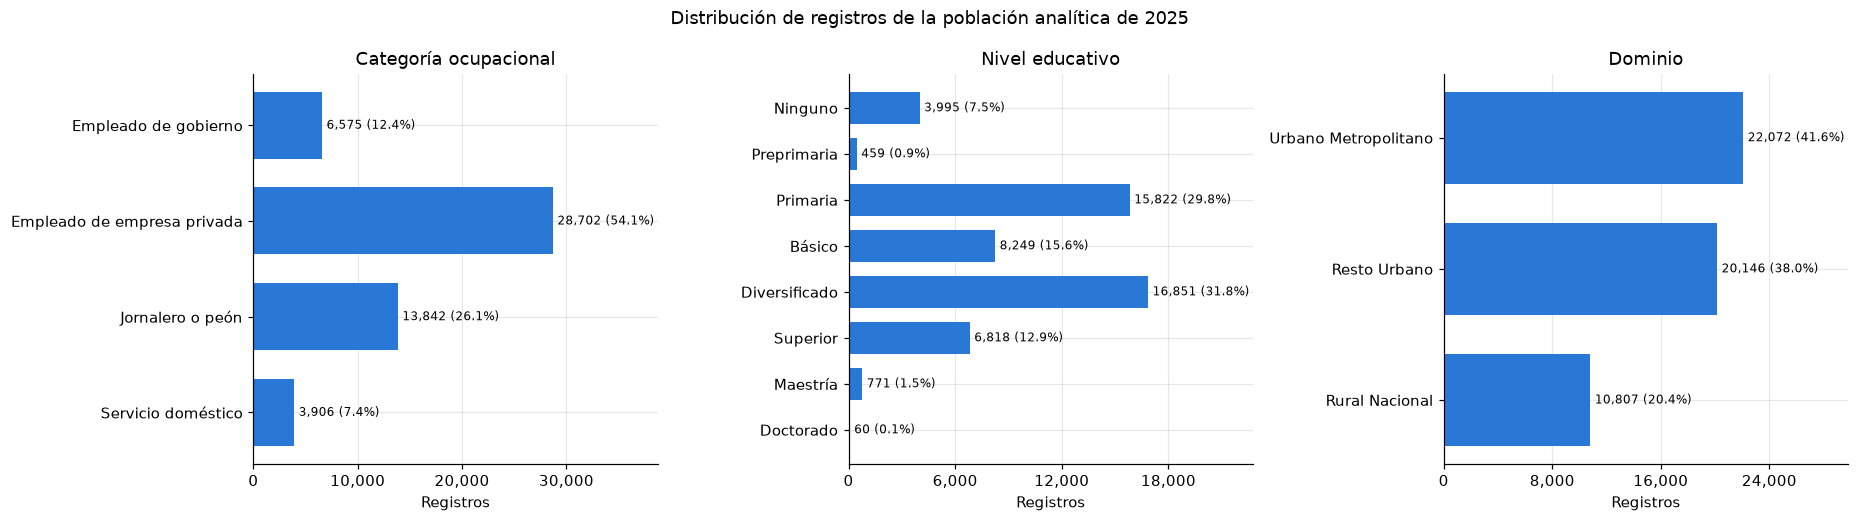

In [21]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4.8))
for eje, (c, titulo) in zip(ejes, [("categoria_ocupacional", "Categoría ocupacional"), ("nivel_educativo", "Nivel educativo"), ("dominio", "Dominio")]):
    orden = [v for k, v in CATEGORIAS[c].items() if c != "categoria_ocupacional" or k <= 4] # solo asalariados
    t = analitica_2025.groupBy(c).count().toPandas().set_index(c).reindex(orden).fillna(0)
    t["porcentaje"] = 100 * t["count"] / t["count"].sum()

    barras = eje.barh(t.index, t["count"], color=AZUL, height=0.7)
    eje.bar_label(barras, labels=[f"{n:,.0f} ({p:.1f}%)" for n, p in zip(t["count"], t["porcentaje"])], padding=3, fontsize=8)
    eje.invert_yaxis()
    eje.margins(x=0.35)
    eje.set_title(titulo)
    eje.set_xlabel("Registros")
    eje.xaxis.set_major_locator(mticker.MaxNLocator(4))
    eje.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

fig.suptitle("Distribución de registros de la población analítica de 2025")
plt.tight_layout()
plt.show()

**¿El salario presenta una distribución simétrica o asimétrica?**

El salario presenta una distribución asimétrica positiva, con un coeficiente de asimetría de 6.00. La mayoría de los registros se concentra entre Q1,800 y Q4,000, que son los percentiles 25 y 75, pero la cola derecha se extiende hasta Q99,000, cuando el percentil 95 es de Q8,000 y el 99 de Q15,000. En la escala logarítmica la distribución se ve mucho más concentrada, aunque se mantiene una cola hacia salarios muy bajos, con un mínimo de Q1. Cabe mencionar que se observan picos en montos redondos como Q3,000 o Q3,500, lo que indica que muchas personas reportan su salario de forma aproximada.

Coeficiente de asimetría del salario: 6.00


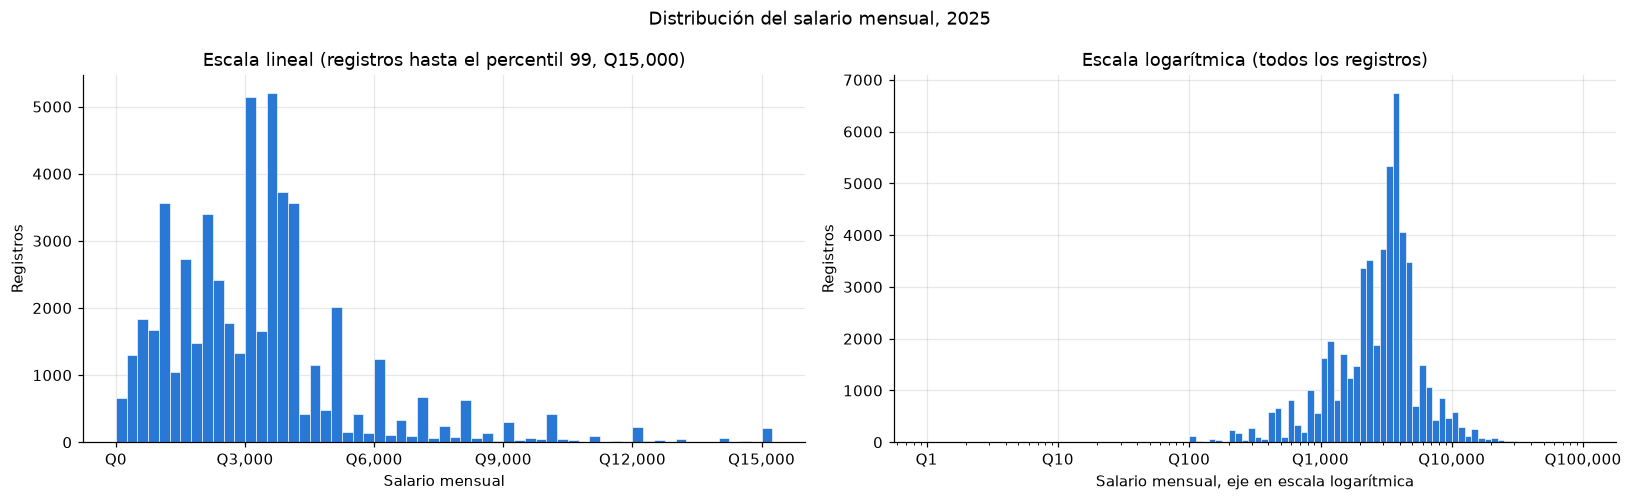

In [22]:
p99 = analitica_2025.agg(F.percentile("salario_mensual", 0.99)).first()[0]
ANCHO, ANCHO_LOG = 250, 0.05 # ancho de cada barra: Q250 en escala lineal, 0.05 en log10

# Histogramas agregados en Spark; a pandas solo pasan los conteos por intervalo
lineal = (
    analitica_2025.filter(F.col("salario_mensual") <= p99)
    .groupBy((F.floor(F.col("salario_mensual") / ANCHO) * ANCHO).alias("desde")).count()
    .orderBy("desde").toPandas()
)
logaritmica = (
    analitica_2025.groupBy((F.floor(F.log10("salario_mensual") / ANCHO_LOG) * ANCHO_LOG).alias("desde")).count()
    .orderBy("desde").toPandas()
)
asimetria = analitica_2025.agg(F.skewness("salario_mensual")).first()[0]
print(f"Coeficiente de asimetría del salario: {asimetria:.2f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.6))
a1.bar(lineal["desde"], lineal["count"], width=ANCHO, align="edge", color=AZUL, edgecolor="white", linewidth=0.4)
a1.set_title(f"Escala lineal (registros hasta el percentil 99, Q{p99:,.0f})")
a1.set_xlabel("Salario mensual")
a1.set_ylabel("Registros")
a1.xaxis.set_major_formatter(quetzales)
a1.xaxis.set_major_locator(mticker.MaxNLocator(6))

inicio = 10 ** logaritmica["desde"]
a2.bar(inicio, logaritmica["count"], width=10 ** (logaritmica["desde"] + ANCHO_LOG) - inicio, align="edge", color=AZUL, edgecolor="white", linewidth=0.4)
a2.set_xscale("log")
a2.set_title("Escala logarítmica (todos los registros)")
a2.set_xlabel("Salario mensual, eje en escala logarítmica")
a2.set_ylabel("Registros")
a2.xaxis.set_major_formatter(quetzales)

fig.suptitle("Distribución del salario mensual, 2025")
plt.tight_layout()
plt.show()

**¿Qué diferencia existe entre su media y su mediana?**

La media es de Q3,421.68 y la mediana de Q3,000, es decir, la media es Q421.68 mayor, un 14.1% por encima de la mediana. Esta diferencia se debe a los salarios altos de la cola derecha, que jalan la media hacia arriba sin afectar a la mediana, es por esto que considero que la mediana representa mejor el salario típico de los registros analizados.

Media: Q3,421.68 | Mediana: Q3,000.00 | Diferencia: Q421.68 (14.1% sobre la mediana)


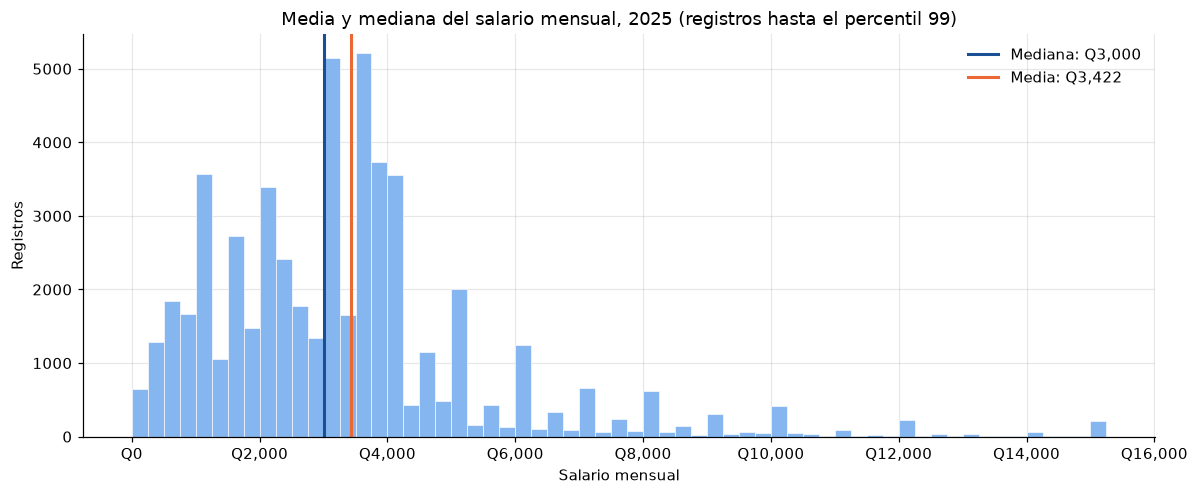

In [23]:
media, mediana = descriptivas.loc["Salario mensual (Q)", ["media", "mediana"]]
print(f"Media: Q{media:,.2f} | Mediana: Q{mediana:,.2f} | Diferencia: Q{media - mediana:,.2f} ({100 * (media / mediana - 1):.1f}% sobre la mediana)")

fig, eje = plt.subplots(figsize=(11, 4.6))
eje.bar(lineal["desde"], lineal["count"], width=ANCHO, align="edge", color=AZUL_CLARO, edgecolor="white", linewidth=0.4)
eje.axvline(mediana, color=AZUL_OSCURO, lw=2, label=f"Mediana: Q{mediana:,.0f}")
eje.axvline(media, color=NARANJA, lw=2, label=f"Media: Q{media:,.0f}")
eje.set_title(f"Media y mediana del salario mensual, 2025 (registros hasta el percentil 99)")
eje.set_xlabel("Salario mensual")
eje.set_ylabel("Registros")
eje.xaxis.set_major_formatter(quetzales)
eje.legend(frameon=False)
plt.tight_layout()
plt.show()

**¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?**

El salario mediano aumenta con cada nivel educativo, pasando de Q1,500 en personas sin educación a Q2,200 en primaria, Q3,600 en diversificado, Q5,000 en superior y Q10,000 en maestría, aunque el valor de doctorado (Q12,000) se basa en solo 60 registros. Por otro lado, entre categorías ocupacionales los empleados de gobierno tienen la mediana más alta (Q5,000), seguidos por los empleados de empresa privada (Q3,568), mientras que los jornaleros o peones (Q1,800) y el servicio doméstico (Q1,000) quedan muy por debajo de la mediana general. Estas diferencias son asociaciones y no implican que la educación o la categoría causen el salario.

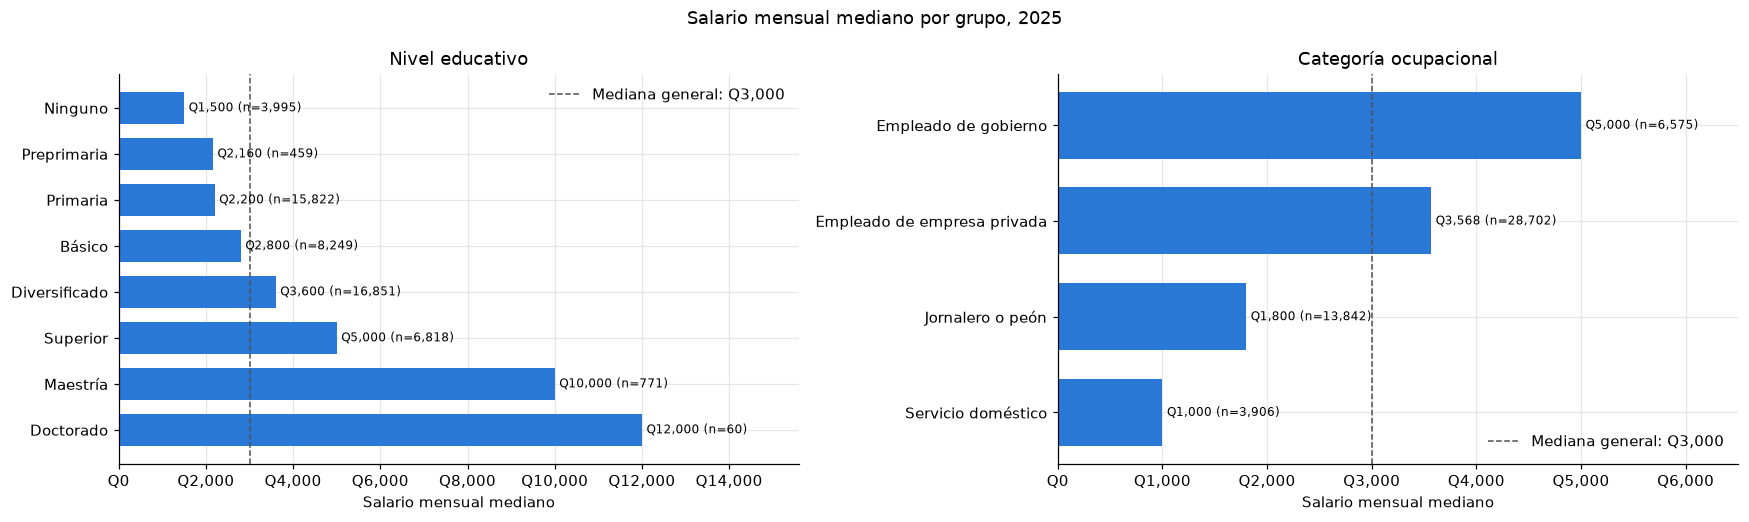

In [24]:
def mediana_por(c):
    return (
        analitica_2025.groupBy(c)
        .agg(F.percentile("salario_mensual", 0.5).alias("mediana"), F.count("*").alias("n"))
        .toPandas().set_index(c)
    )


educacion = mediana_por("nivel_educativo").reindex(list(CATEGORIAS["nivel_educativo"].values())).dropna()
categoria = mediana_por("categoria_ocupacional").sort_values("mediana", ascending=False)

fig, ejes = plt.subplots(1, 2, figsize=(16, 4.8))
for eje, t, titulo, ubicacion in [(ejes[0], educacion, "Nivel educativo", "upper right"), (ejes[1], categoria, "Categoría ocupacional", "lower right")]:
    barras = eje.barh(t.index, t["mediana"], color=AZUL, height=0.7)
    eje.bar_label(barras, labels=[f"Q{m:,.0f} (n={n:,.0f})" for m, n in zip(t["mediana"], t["n"])], padding=3, fontsize=8)
    eje.axvline(mediana, color=GRIS, lw=1, ls="--", label=f"Mediana general: Q{mediana:,.0f}")
    eje.invert_yaxis()
    eje.margins(x=0.3)
    eje.set_title(titulo)
    eje.set_xlabel("Salario mensual mediano")
    eje.xaxis.set_major_formatter(quetzales)
    eje.legend(frameon=False, loc=ubicacion)

fig.suptitle("Salario mensual mediano por grupo, 2025")
plt.tight_layout()
plt.show()

**¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?**

El tamaño de la muestra se mantiene estable entre el primer y el tercer trimestre, alrededor de 13,450 registros, y baja a 12,664 en el cuarto trimestre, un 6% menos. El salario mediano se mantiene en Q3,000 en los dos primeros trimestres y sube a Q3,200 en el tercero y el cuarto, mientras que la media crece de forma continua de Q3,315.63 a Q3,544.57. El cambio es moderado, pero cabe mencionar que el cuarto trimestre, que se usará para validación, tiene salarios ligeramente más altos que los trimestres de entrenamiento.

,periodo_archivo,registros,mediana,media
0,2025T1,13419,3000.0,3315.63
1,2025T2,13492,3000.0,3364.57
2,2025T3,13450,3200.0,3469.07
3,2025T4,12664,3200.0,3544.57


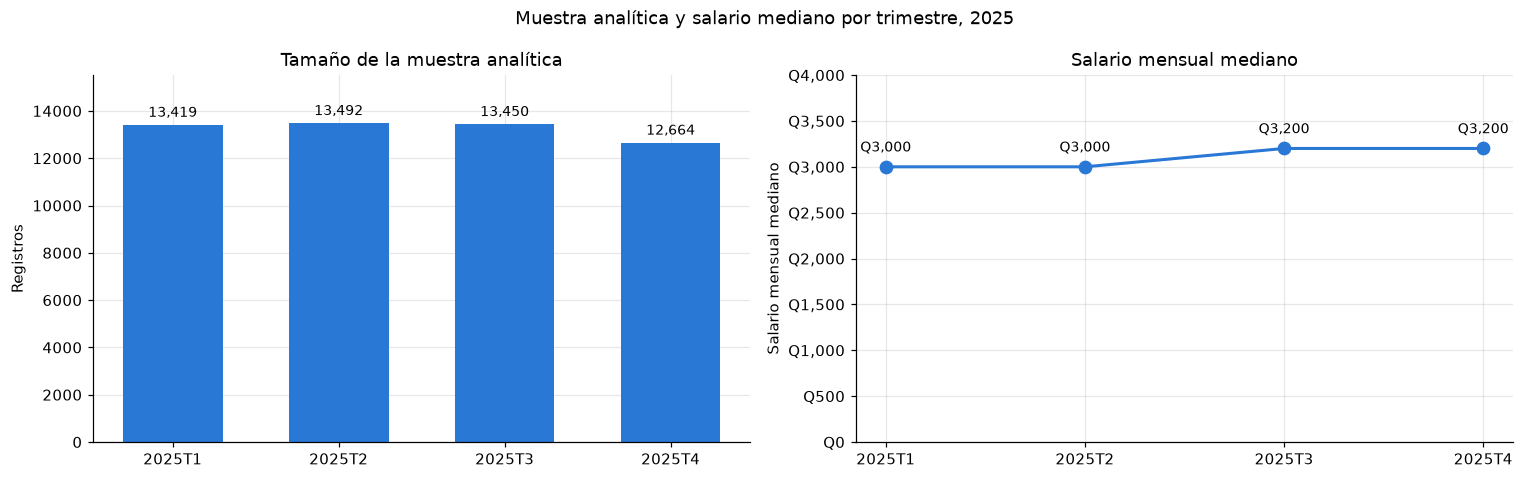

In [25]:
trimestres = (
    analitica_2025.groupBy("periodo_archivo")
    .agg(F.count("*").alias("registros"), F.percentile("salario_mensual", 0.5).alias("mediana"), F.mean("salario_mensual").alias("media"))
    .orderBy("periodo_archivo").toPandas().round(2)
)
display(trimestres)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.4))
barras = a1.bar(trimestres["periodo_archivo"], trimestres["registros"], color=AZUL, width=0.6)
a1.bar_label(barras, labels=[f"{n:,}" for n in trimestres["registros"]], padding=3, fontsize=9)
a1.set_title("Tamaño de la muestra analítica")
a1.set_ylabel("Registros")
a1.margins(y=0.15)

a2.plot(trimestres["periodo_archivo"], trimestres["mediana"], color=AZUL, lw=2, marker="o", markersize=8)
for x, y in zip(trimestres["periodo_archivo"], trimestres["mediana"]):
    a2.annotate(f"Q{y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
a2.set_title("Salario mensual mediano")
a2.set_ylabel("Salario mensual mediano")
a2.yaxis.set_major_formatter(quetzales)
a2.set_ylim(0, trimestres["mediana"].max() * 1.25) # eje desde 0 para no exagerar el cambio

fig.suptitle("Muestra analítica y salario mediano por trimestre, 2025")
plt.tight_layout()
plt.show()

## **3. Relaciones entre variables numéricas**

In [26]:
from matplotlib.colors import LinearSegmentedColormap
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

VARIABLES_CORRELACION = {
    "salario_mensual": "Salario",
    "edad": "Edad",
    "antiguedad": "Antigüedad",
    "horas_semanales": "Horas habituales",
}

# Correlación de Pearson sobre todos los registros elegibles de 2025
vectores = VectorAssembler(inputCols=list(VARIABLES_CORRELACION), outputCol="variables").transform(analitica_2025).select("variables")
matriz = Correlation.corr(vectores, "variables", method="pearson").first()[0].toArray()

etiquetas = list(VARIABLES_CORRELACION.values())
correlaciones = pd.DataFrame(matriz, index=etiquetas, columns=etiquetas).round(3)
correlaciones

,Salario,Edad,Antigüedad,Horas habituales
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas habituales,0.076,-0.105,-0.062,1.000


**¿Qué variables presentan mayor asociación lineal con el salario?**

La antigüedad es la variable con mayor asociación lineal con el salario (0.18), seguida por la edad (0.15) y, muy por detrás, las horas habituales (0.08). Sin embargo, en el mapa de calor la fila del salario tiene los colores más claros, ya que las tres correlaciones son débiles. Esto tiene sentido porque la antigüedad y la edad reflejan la experiencia acumulada, que suele traducirse en ascensos y aumentos, pero el salario depende mucho más de factores como el nivel educativo y la categoría ocupacional, donde en la sección anterior se vieron diferencias de hasta diez veces en el salario mediano. En el caso de las horas, la relación casi nula podría explicarse porque las jornadas largas son comunes en ocupaciones de bajo salario, como jornaleros y servicio doméstico. Cabe mencionar que la correlación de Pearson solo mide relaciones lineales y es sensible a los salarios extremos, por lo que considero que un modelo que use solo estas tres variables numéricas tendría una capacidad predictiva muy limitada.

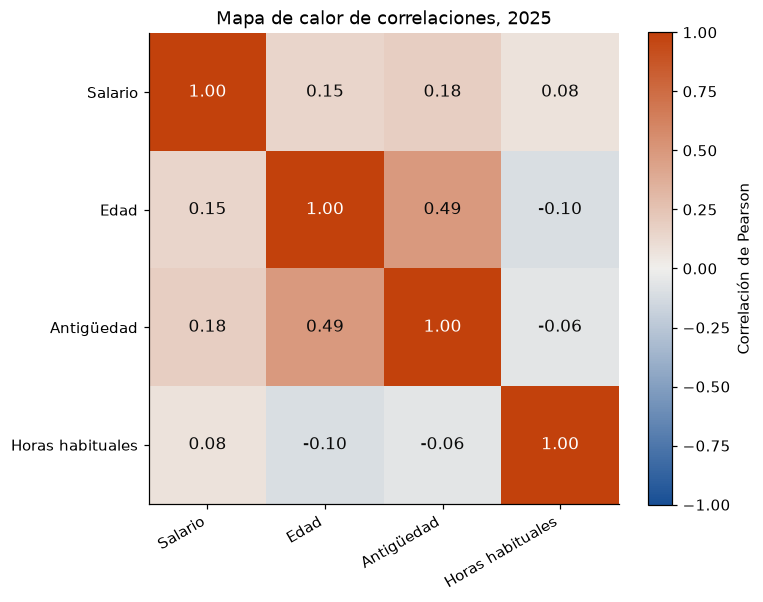

In [27]:
divergente = LinearSegmentedColormap.from_list("divergente", [AZUL_OSCURO, "#f0efec", "#c2410c"])

fig, eje = plt.subplots(figsize=(7, 5.6))
imagen = eje.imshow(correlaciones.values, cmap=divergente, vmin=-1, vmax=1)
eje.set_xticks(range(len(etiquetas)), etiquetas, rotation=30, ha="right")
eje.set_yticks(range(len(etiquetas)), etiquetas)
eje.grid(False)
for i in range(len(etiquetas)):
    for j in range(len(etiquetas)):
        valor = correlaciones.iloc[i, j]
        eje.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=11, color="white" if abs(valor) > 0.6 else "#0b0b0b")
fig.colorbar(imagen, ax=eje, label="Correlación de Pearson")
eje.set_title("Mapa de calor de correlaciones, 2025")
plt.tight_layout()
plt.show()

**¿Existe relación entre edad y antigüedad?**

Sí, la edad y la antigüedad tienen una correlación positiva moderada de 0.49, que es la celda más oscura del mapa de calor fuera de la diagonal. Esto tiene sentido porque la antigüedad solo se puede acumular con los años, de tal forma que una persona joven no puede tener mucha antigüedad, mientras que una persona mayor sí puede tenerla. No obstante, la relación no es más fuerte porque una persona mayor también puede tener poca antigüedad si cambió de empleo recientemente, es por esto que en la gráfica los puntos forman un triángulo, con antigüedades bajas en todas las edades y antigüedades altas solo en edades mayores.

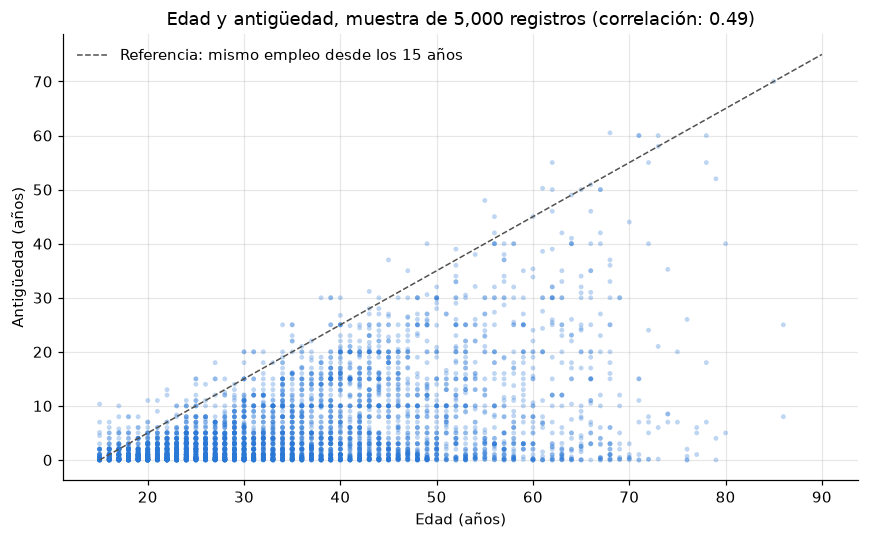

In [28]:
# Para dibujar se usa una muestra de 5,000 registros; la correlación viene de todos los registros
muestra = analitica_2025.select("edad", "antiguedad").orderBy(F.rand(seed=42)).limit(5000).toPandas()

fig, eje = plt.subplots(figsize=(8, 5))
eje.scatter(muestra["edad"], muestra["antiguedad"], s=10, alpha=0.3, color=AZUL, edgecolors="none")
eje.plot([15, 90], [0, 75], color=GRIS, lw=1, ls="--", label="Referencia: mismo empleo desde los 15 años")
eje.set_title(f"Edad y antigüedad, muestra de {len(muestra):,} registros (correlación: {correlaciones.loc['Edad', 'Antigüedad']:.2f})")
eje.set_xlabel("Edad (años)")
eje.set_ylabel("Antigüedad (años)")
eje.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()